In [5]:
# !pip install librosa
!pip install scikit-image 

   ---------------------------------------- 0.0/12.0 MB ? eta -:--:--
   -------- ------------------------------- 2.6/12.0 MB 14.2 MB/s eta 0:00:01
   --------------- ------------------------ 4.7/12.0 MB 12.3 MB/s eta 0:00:01
   ----------------- ---------------------- 5.2/12.0 MB 8.6 MB/s eta 0:00:01
   ------------------- -------------------- 5.8/12.0 MB 7.3 MB/s eta 0:00:01
   -------------------- ------------------- 6.3/12.0 MB 6.5 MB/s eta 0:00:01
   ------------------------ --------------- 7.3/12.0 MB 5.9 MB/s eta 0:00:01
   ---------------------------- ----------- 8.7/12.0 MB 6.0 MB/s eta 0:00:01
   --------------------------------- ------ 10.0/12.0 MB 6.0 MB/s eta 0:00:01
   ----------------------------------- ---- 10.7/12.0 MB 5.8 MB/s eta 0:00:01
   -------------------------------------- - 11.5/12.0 MB 5.5 MB/s eta 0:00:01
   ---------------------------------------- 12.0/12.0 MB 5.3 MB/s  0:00:02

   ---------------------------------------- 0/3 [tifffile]
   -----------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [6]:
import torch
from torch import nn
from torch.optim import Adam
import librosa
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import time
from skimage.transform import resize

In [31]:
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Device is:-", device)

Device is:- cuda


In [32]:
df = pd.read_csv("./files_paths.csv")

df.head()

,FilePath,Class
0,./Dataset/Mohammed_Aluhaidan/lohaidan_171.wav,Mohammed_Aluhaidan
1,./Dataset/Mohammed_Aluhaidan/lohaidan_159.wav,Mohammed_Aluhaidan
2,./Dataset/Mohammed_Aluhaidan/lohaidan_401.wav,Mohammed_Aluhaidan
3,./Dataset/Mohammed_Aluhaidan/lohaidan_367.wav,Mohammed_Aluhaidan
4,./Dataset/Mohammed_Aluhaidan/lohaidan_373.wav,Mohammed_Aluhaidan


In [33]:
df["Class"].unique()

<StringArray>
[  'Mohammed_Aluhaidan',     'Yasser_Aldossary',      'Maher_Almuaiqly',
      'Nasser_Alqutami', 'AbdulBari_Althubaity',       'Bander_Balilah',
       'Ali_Alhothaify',       'Saud_Alshuraim',       'Mohammed_Ayoub',
 'AbdulRahman_Alsudais',        'Saad_Alghamdi',   'Abdullah_Albuaijan']
Length: 12, dtype: str

In [34]:
df.shape

(6687, 2)

In [35]:
label_encoder = LabelEncoder()
df['Class'] = label_encoder.fit_transform(df['Class'])

train = df.sample(frac = 0.7, random_state=7)
test = df.drop(train.index)

val = test.sample(frac = 0.5, random_state=7)
test = test.drop(val.index)


print(train.shape, test.shape, val.shape)

(4681, 2) (1003, 2) (1003, 2)


In [51]:


class CustomAudioClass(Dataset):
    def __init__(self, dataframe):
        self.dataframe = dataframe
        self.labels = torch.tensor(list(dataframe['Class'])).type(torch.LongTensor).to(device)
        self.audios = [torch.tensor(self.get_spectogram(path)).type(torch.FloatTensor) for path in dataframe['FilePath']]

    def __len__(self):
        return self.dataframe.shape[0]

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx,0]
        label = torch.Tensor(self.labels[idx]).to(device)

        audio = self.audios[idx].unsqueeze(0).to(device)

        return audio, label


    def get_spectogram(self, file_path):
        sr = 22050
        duration = 5


        img_height = 128
        img_width = 256

        signal, sr = librosa.load(file_path, sr = sr, duration=duration)


        spec = librosa.feature.melspectrogram(y = signal, sr=sr, n_fft=2048, hop_length=512, n_mels = 128)

        spec_db = librosa.power_to_db(spec, ref=np.max)


        spec_resized = librosa.util.fix_length(spec_db, size = (duration*sr) // 512+1)
        spec_resized = resize(spec_resized, (img_height, img_width), anti_aliasing=True)

        return spec_resized

In [52]:
train_dataset = CustomAudioClass(dataframe=train)
val_dataset = CustomAudioClass(dataframe=val)
test_dataset = CustomAudioClass(dataframe=test)

In [53]:
LR = 1e-4
BATCH_SIZE = 16
EPOCHS = 25

In [54]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [55]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pooling = nn.MaxPool2d(2,2)
        self.relu = nn.ReLU()

        self.flatten = nn.Flatten()
        self.linear1 = nn.Linear((64*16*32), 4096)
        self.linear2 = nn.Linear(4096, 1024)
        self.linear3 = nn.Linear(1024, 512)
        self.output = nn.Linear(512, len(df['Class'].unique()))

        self.dropout = nn.Dropout(0.5)


    def forward(self, x):
        x = self.conv1(x)
        x = self.pooling(x)
        x = self.conv2(x)
        x = self.pooling(x)
        x = self.conv3(x)
        x = self.pooling(x)

        x = self.relu(x)

        x = x.view(x.size(0),-1)
        x = self.flatten(x)
        x = self.linear1(x)
        x = self.dropout(x)
        x = self.linear2(x)
        x = self.dropout(x)
        x = self.linear3(x)
        x = self.dropout(x)
        x = self.output(x)

        return x





In [56]:
model = Net().to(device)

In [57]:
from torchsummary import summary

summary(model, (1,128,256))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 128, 256]             160
         MaxPool2d-2          [-1, 16, 64, 128]               0
            Conv2d-3          [-1, 32, 64, 128]           4,640
         MaxPool2d-4           [-1, 32, 32, 64]               0
            Conv2d-5           [-1, 64, 32, 64]          18,496
         MaxPool2d-6           [-1, 64, 16, 32]               0
              ReLU-7           [-1, 64, 16, 32]               0
           Flatten-8                [-1, 32768]               0
            Linear-9                 [-1, 4096]     134,221,824
          Dropout-10                 [-1, 4096]               0
           Linear-11                 [-1, 1024]       4,195,328
          Dropout-12                 [-1, 1024]               0
           Linear-13                  [-1, 512]         524,800
          Dropout-14                  [

In [58]:
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr = LR)

In [60]:
import time

start_time = time.time()


total_loss_train_plot = []
total_loss_validation_plot = []
total_acc_train_plot = []
total_acc_validation_plot = []


for epoch in range(EPOCHS):
    total_acc_train = 0
    total_loss_train = 0
    total_acc_val = 0
    total_loss_val = 0

    for inputs, labels in train_loader:
        
        outputs = model(inputs)
        train_loss = criterion(outputs, labels)
        total_loss_train += train_loss.item()

        train_loss.backward()  

        train_acc = (torch.argmax(outputs,axis=1)==labels).sum().item()
        total_acc_train+=train_acc


        

        optimizer.step()
        optimizer.zero_grad()

        
        # _, predicted = torch.max(outputs.data, 1)
        # total_acc_train += (predicted == labels).sum().item()


    with torch.no_grad():
        for inputs, labels in val_loader:
            outputs = model(inputs)
            val_loss = criterion(outputs, labels)
            total_loss_val += val_loss.item()

            val_acc = (torch.argmax(outputs,axis=1)==labels).sum().item()
            total_acc_val+=val_acc

            # _, predicted = torch.max(outputs.data, 1)
            # total_acc_val += (predicted == labels).sum().item()


    total_loss_train_plot.append(round(total_loss_train/1000, 4))
    total_loss_validation_plot.append(round(total_loss_val/1000, 4))

    total_acc_train_plot.append(round(100 * total_acc_train / len(train_dataset), 4))
    total_acc_validation_plot.append(round(100 * total_acc_val / len(val_dataset), 4))


    print(f'''end=of epoch {epoch+1}/{EPOCHS} |
          Train Loss: {round(total_loss_train/1000, 4)} |   
            Validation Loss: {round(total_loss_val/1000, 4)} |
            Train Accuracy: {round(100 * total_acc_train / len(train_dataset), 4)} |
            Validation Accuracy: {round(100 * total_acc_val / len(val_dataset), 4)}''')

print("Total time is:-", round(time.time() - start_time, 4))
    

end=of epoch 1/25 |
          Train Loss: 0.8366 |   
            Validation Loss: 0.047 |
            Train Accuracy: 45.7381 |
            Validation Accuracy: 76.5703
end=of epoch 2/25 |
          Train Loss: 0.1686 |   
            Validation Loss: 0.0256 |
            Train Accuracy: 82.1833 |
            Validation Accuracy: 88.6341
end=of epoch 3/25 |
          Train Loss: 0.0932 |   
            Validation Loss: 0.0187 |
            Train Accuracy: 90.4294 |
            Validation Accuracy: 91.0269
end=of epoch 4/25 |
          Train Loss: 0.0721 |   
            Validation Loss: 0.0184 |
            Train Accuracy: 92.6511 |
            Validation Accuracy: 91.2263
end=of epoch 5/25 |
          Train Loss: 0.0603 |   
            Validation Loss: 0.0167 |
            Train Accuracy: 93.7193 |
            Validation Accuracy: 92.6221
end=of epoch 6/25 |
          Train Loss: 0.0501 |   
            Validation Loss: 0.0179 |
            Train Accuracy: 94.702 |
            Valid

In [61]:
with torch.no_grad():
    total_acc_test = 0
    total_loss_test = 0

    for inputs, labels in test_loader:
        outputs = model(inputs)
        acc = (torch.argmax(outputs,axis=1)==labels).sum().item()

        total_acc_test += acc


        test_loss = criterion(outputs, labels)
        total_loss_test += test_loss.item()

        

    print(f'''Test Loss: {round(total_loss_test/1000, 4)} |
          Test Accuracy: {round(100 * total_acc_test / len(test_dataset), 4)}''')

Test Loss: 0.0322 |
          Test Accuracy: 94.0179


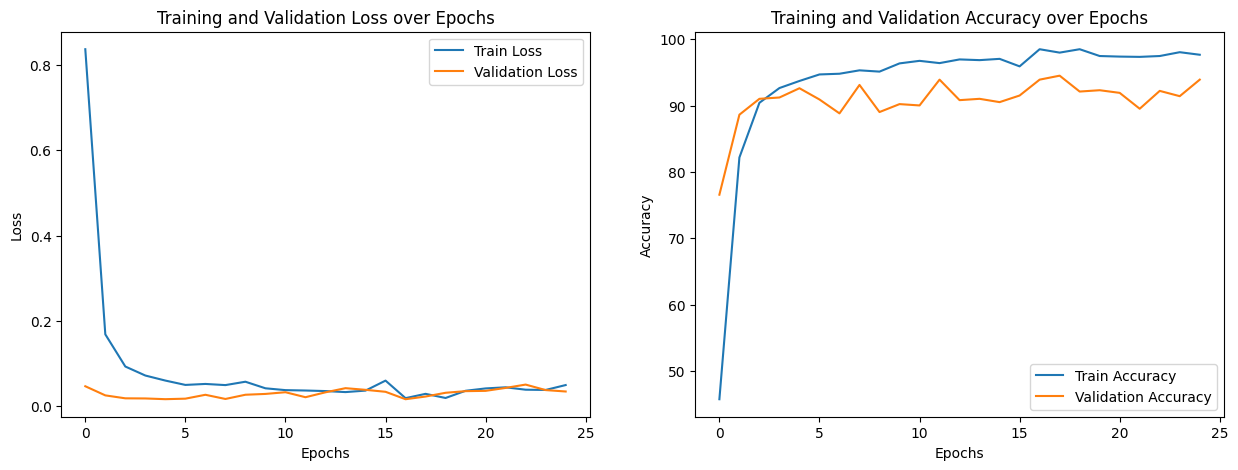

In [62]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

axs[0].plot(total_loss_train_plot, label='Train Loss')
axs[0].plot(total_loss_validation_plot, label='Validation Loss')
axs[0].set_title('Training and Validation Loss over Epochs')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].legend()



axs[1].plot(total_acc_train_plot, label='Train Accuracy')
axs[1].plot(total_acc_validation_plot, label='Validation Accuracy')
axs[1].set_title('Training and Validation Accuracy over Epochs')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].legend()

plt.show()